
# Standard SPOD per Component (u, v, axial w) on a Denser Masked Grid

This notebook performs a **pragmatic Spectral POD (SPOD)** separately for each velocity component on a **denser** version of your masked grid.  
We upscale the original 15×15 mask by 4× in each direction → **60×60** (≈16× more points), keeping **zero padding** and the same general shape.

**Notes for this application**
- The **axial velocity `w`** represents the component **normal to the 2‑D plane** (flowing *through* the slice).
- The flow is mostly through the slice, so **`w` amplitudes are notably larger** than `u` and `v`.
- We use a standard Welch-based SPOD: Hann window, 50% overlap, snapshot method (eigen-decomposition of the K×K cross-spectral density per frequency).



## 1) Build the denser mask and synthesize velocity data

We upscale the provided 15×15 mask to 60×60 using nearest-neighbor (block) upsampling, then generate synthetic (u,v,w) with:
- strong axial mean flow w through the slice,
- coherent oscillations at a few frequencies (e.g., 4 Hz and 8 Hz),
- smaller in-plane components u and v,
- light noise.


RMS(u)=0.007, RMS(v)=0.009, RMS(w)=0.801  (expect w >> u,v)


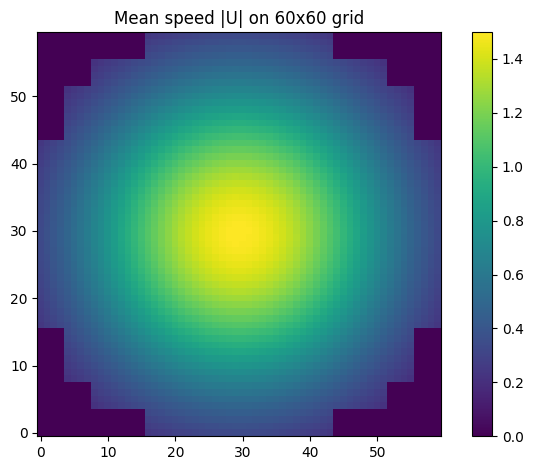

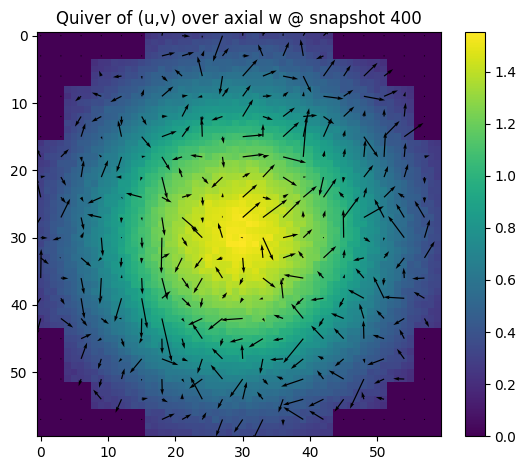

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Base 15x15 mask
mask15 = np.array([
[0,0,0,0,1,1,1,1,1,1,1,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,1,1,1,0,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,0,1,1,1,1,1,1,1,1,1,1,1,0,0],
[0,0,0,0,1,1,1,1,1,1,1,0,0,0,0],
], dtype=np.uint8).astype(bool)

# Upscale by factor s=4 in each direction → 60x60 (16x points)
s = 4
mask = np.kron(mask15, np.ones((s, s), dtype=bool))
H, W = mask.shape
assert (H, W) == (60, 60)

# Time sampling
T = 1024           # snapshots
dt = 0.01          # 100 Hz sampling
t = np.arange(T) * dt

# Coordinates in [-1,1] for smooth patterns
yy, xx = np.mgrid[0:H, 0:W]
x = (xx - (W-1)/2) / ((W-1)/2)
y = (yy - (H-1)/2) / ((H-1)/2)
r2 = x**2 + y**2
r = np.sqrt(r2)

def norm_masked(arr, mask):
    v = arr[mask]
    n = np.linalg.norm(v) + 1e-12
    out = np.zeros_like(arr, dtype=float)
    out[mask] = arr[mask] / n
    return out

# Axial mean flow (through-slice) — notably larger
W0 = 1.5 * np.exp(-1.5*r2)

# Dominant frequency
f0 = 4.0   # Hz (target multi-rank at this f)
f2 = 8.0   # Hz (secondary)

# Spatial patterns (normalized on the mask)
swirl      = norm_masked(np.exp(-2.0*r2), mask)
ux_swirl   = norm_masked(-y * np.exp(-2.0*r2), mask)
uy_swirl   = norm_masked( x * np.exp(-2.0*r2), mask)
shear_x    = norm_masked(np.sin(2*np.pi*2.0*x) * np.exp(-1.0*r2), mask)
shear_y    = norm_masked(np.sin(2*np.pi*2.0*y) * np.exp(-1.0*r2), mask)
dipole_u   = norm_masked((x*y) * np.exp(-1.2*r2), mask)
dipole_v   = norm_masked((y*(1-x**2)) * np.exp(-1.2*r2), mask)
ring_w     = norm_masked(np.exp(-((r-0.45)**2)/0.02), mask)  # ring feature
bump_uv    = norm_masked(np.exp(-((x-0.3)**2 + (y+0.2)**2)/0.12), mask)

# --- Helper: smooth random envelope and phase wander ---
rng = np.random.default_rng(11)

def smooth_envelope(T, sigma=0.5, alpha=0.995):
    e = rng.normal(0.0, sigma, size=T)
    out = np.empty(T)
    out[0] = e[0]
    for k in range(1, T):
        out[k] = alpha*out[k-1] + (1-alpha)*e[k]
    return out

def phase_wander(T, step=0.05):
    dphi = rng.normal(0.0, step, size=T)
    phi = np.cumsum(dphi)
    phi += rng.uniform(0, 2*np.pi)
    return phi

# Create 3 independent 4 Hz processes per component (independent envelopes + phases)
phi_u = [phase_wander(T, 0.06) for _ in range(3)]
env_u = [1.0 + 0.4*smooth_envelope(T, 0.6, 0.993) for _ in range(3)]

phi_v = [phase_wander(T, 0.06) for _ in range(3)]
env_v = [1.0 + 0.4*smooth_envelope(T, 0.6, 0.993) for _ in range(3)]

phi_w = [phase_wander(T, 0.06) for _ in range(3)]
env_w = [1.0 + 0.4*smooth_envelope(T, 0.6, 0.993) for _ in range(3)]

# Amplitudes (keep w >> u,v overall)
Au = [0.28, 0.22, 0.18]     # u amplitudes at f0
Av = [0.22, 0.18, 0.14]     # v amplitudes at f0
Aw = [0.70, 0.45, 0.35]     # w amplitudes at f0
Bu = 0.05                   # small 8 Hz in u
Bv = 0.05                   # small 8 Hz in v
Bw = 0.30                   # noticeable 8 Hz in w

# Allocate fields
u = np.zeros((T, H, W), dtype=float)
v = np.zeros((T, H, W), dtype=float)
w = np.zeros((T, H, W), dtype=float)

for k in range(T):
    s0 = 2*np.pi*f0*t[k]
    s2 = 2*np.pi*f2*t[k]

    # u: three independent 4 Hz processes on distinct shapes + tiny 8 Hz
    u_field = (Au[0]*env_u[0][k]*np.sin(s0 + phi_u[0][k])*ux_swirl +
               Au[1]*env_u[1][k]*np.sin(s0 + phi_u[1][k])*shear_x  +
               Au[2]*env_u[2][k]*np.sin(s0 + phi_u[2][k])*dipole_u  +
               Bu*np.sin(s2)*bump_uv)

    # v: three independent 4 Hz processes (smaller) + tiny 8 Hz
    v_field = (Av[0]*env_v[0][k]*np.sin(s0 + phi_v[0][k])*uy_swirl +
               Av[1]*env_v[1][k]*np.sin(s0 + phi_v[1][k])*shear_y  +
               Av[2]*env_v[2][k]*np.sin(s0 + phi_v[2][k])*dipole_v  +
               Bv*np.sin(s2)*bump_uv)

    # w: strong mean + three independent 4 Hz processes + secondary 8 Hz
    w_field = (W0 +
               Aw[0]*env_w[0][k]*np.sin(s0 + phi_w[0][k])*swirl   +
               Aw[1]*env_w[1][k]*np.sin(s0 + phi_w[1][k])*shear_x +
               Aw[2]*env_w[2][k]*np.sin(s0 + phi_w[2][k])*ring_w  +
               Bw*np.sin(s2)*swirl)

    # Noise and mask
    u[k] = u_field * mask + 0.005*np.random.standard_normal((H,W))*mask
    v[k] = v_field * mask + 0.008*np.random.standard_normal((H,W))*mask
    w[k] = w_field * mask + 0.015*np.random.standard_normal((H,W))*mask

# Quick sanity: RMS of components (should show w >> u,v)
rms_u = np.sqrt((u[:, mask]**2).mean())
rms_v = np.sqrt((v[:, mask]**2).mean())
rms_w = np.sqrt((w[:, mask]**2).mean())
print(f"RMS(u)={rms_u:.3f}, RMS(v)={rms_v:.3f}, RMS(w)={rms_w:.3f}  (expect w >> u,v)")

# Initial visuals
speed = np.sqrt(u**2 + v**2 + w**2)
mean_speed = speed.mean(axis=0)
plt.figure()
plt.imshow(mean_speed, origin='lower')
plt.colorbar()
plt.title('Mean speed |U| on 60x60 grid')
plt.tight_layout()
plt.show()

# --- Quiver visualization (in-plane vectors over axial background) ---
k = min(400, T-1)
step = 3  # decimate for readability
fig, ax = plt.subplots()
im = ax.imshow(w[k], origin='lower')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.quiver(xx[::step,::step], yy[::step,::step], u[k,::step,::step], v[k,::step,::step])
ax.set_title(f'Quiver of (u,v) over axial w @ snapshot {k}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


> **Note:** To get non-trivial **multiple SPOD modes at the same frequency**, a single pure tone with fixed spatial pattern is **rank‑1** in the CSD.  
> We therefore drive each component with **three independent 4 Hz processes** (different spatial patterns, **independent phase wander** and **slow envelopes**).  
> That yields a higher‑rank CSD at the 4 Hz bin so **modes 1–3** carry coherent structure rather than noise.



## 2) SPOD utilities (component-wise)


In [2]:
def flatten_by_mask(stack, mask):
    """stack: (T,H,W) -> X: (M,T) selecting valid points only."""
    T, H, W = stack.shape
    midx = mask
    M = int(midx.sum())
    X = np.zeros((M, T), dtype=float)
    for k in range(T):
        X[:, k] = stack[k][midx]
    return X

def unmask(vec, mask, H, W):
    """vec: (M,) -> image (H,W) with zeros in padding."""
    img = np.zeros((H, W), dtype=vec.dtype)
    img[mask] = vec
    return img

def welch_blocks(X, nfft, overlap, dt):
    """X: (M,T) centered -> return Xhat_blocks: (K x M x F), freqs, win_norm, hop."""
    M, T = X.shape
    hop = int(nfft*(1-overlap))
    assert hop > 0 and nfft <= T
    win = np.hanning(nfft)
    F = nfft//2 + 1
    blocks = []
    for t0 in range(0, T - nfft + 1, hop):
        seg = X[:, t0:t0+nfft] * win[None, :]
        Xhat = np.fft.rfft(seg, axis=1)  # (M x F)
        blocks.append(Xhat)
    Xhat_blocks = np.stack(blocks, axis=0)   # (K x M x F)
    freqs = np.fft.rfftfreq(nfft, d=dt)
    win_norm = (win**2).sum()
    return Xhat_blocks, freqs, win_norm, hop, F

def spod_component(stack, mask, dt, nfft=256, overlap=0.5, nmodes=6):
    """Return (freqs, evals_top[F,nmodes], modes_top[F,M,nmodes])."""
    X = flatten_by_mask(stack, mask)   # (M,T)
    mean = X.mean(axis=1, keepdims=True)
    Xc = X - mean

    Xhat_blocks, freqs, win_norm, hop, F = welch_blocks(Xc, nfft, overlap, dt)
    K, M, F = Xhat_blocks.shape

    evals_top = np.zeros((F, nmodes))
    modes_top = np.zeros((F, M, nmodes), dtype=complex)

    for fi in range(F):
        # Y (M x K): windowed FFT snapshots divided by sqrt(win_norm)
        Y = (Xhat_blocks[:, :, fi].T) / np.sqrt(win_norm)   # (M x K)
        C = (Y.conj().T @ Y) / K                            # (K x K)
        lam, Alpha = np.linalg.eigh(C)                      # ascending
        idx = np.argsort(lam)[::-1]
        lam = lam[idx]
        Alpha = Alpha[:, idx]
        cut = min(nmodes, len(lam))
        for m in range(cut):
            if lam[m] <= 0: 
                continue
            phi = (Y @ Alpha[:, m]) / np.sqrt(K*lam[m])     # (M,)
            evals_top[fi, m] = lam[m]
            modes_top[fi, :, m] = phi

    return freqs, evals_top, modes_top


## 3) Run SPOD for each component and plot spectra


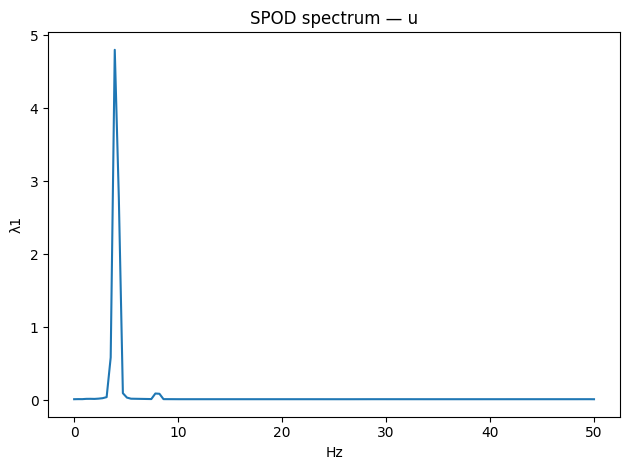

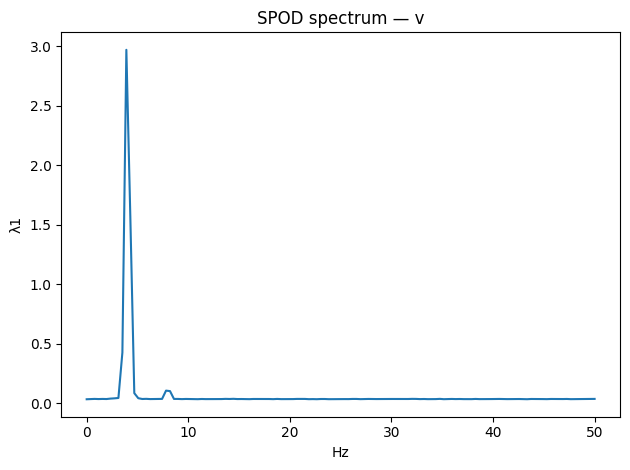

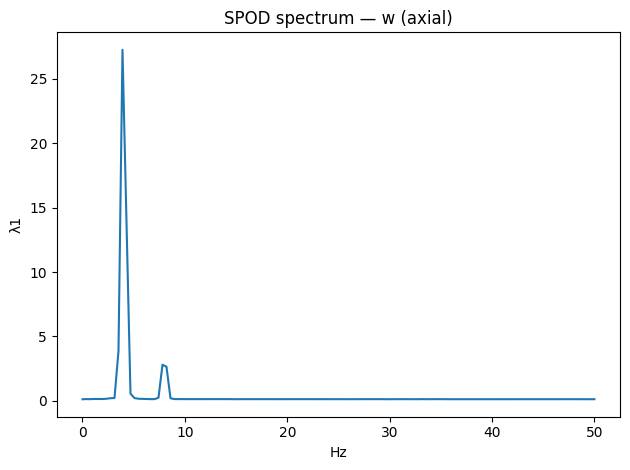

Peak freqs: u≈3.91 Hz, v≈3.91 Hz, w≈3.91 Hz


In [3]:
# Parameters for SPOD
nfft = 256
overlap = 0.5
nmodes = 6

# Compute SPOD separately
freqs_u, evals_u, modes_u = spod_component(u, mask, dt, nfft=nfft, overlap=overlap, nmodes=nmodes)
freqs_v, evals_v, modes_v = spod_component(v, mask, dt, nfft=nfft, overlap=overlap, nmodes=nmodes)
freqs_w, evals_w, modes_w = spod_component(w, mask, dt, nfft=nfft, overlap=overlap, nmodes=nmodes)

# Plot leading-eigenvalue spectra (one per component)
plt.figure(); plt.plot(freqs_u, evals_u[:,0]); plt.xlabel('Hz'); plt.ylabel('λ1'); plt.title('SPOD spectrum — u'); plt.tight_layout(); plt.show()
plt.figure(); plt.plot(freqs_v, evals_v[:,0]); plt.xlabel('Hz'); plt.ylabel('λ1'); plt.title('SPOD spectrum — v'); plt.tight_layout(); plt.show()
plt.figure(); plt.plot(freqs_w, evals_w[:,0]); plt.xlabel('Hz'); plt.ylabel('λ1'); plt.title('SPOD spectrum — w (axial)'); plt.tight_layout(); plt.show()

# Identify peak freq for each component
fi_u = int(np.argmax(evals_u[:,0])); f_u = freqs_u[fi_u]
fi_v = int(np.argmax(evals_v[:,0])); f_v = freqs_v[fi_v]
fi_w = int(np.argmax(evals_w[:,0])); f_w = freqs_w[fi_w]
print(f'Peak freqs: u≈{f_u:.2f} Hz, v≈{f_v:.2f} Hz, w≈{f_w:.2f} Hz')


## 4) 2×3 subplots of the first 6 modes (per component) at the peak frequency

We plot the **real parts** of the modes (common for SPOD visualization).


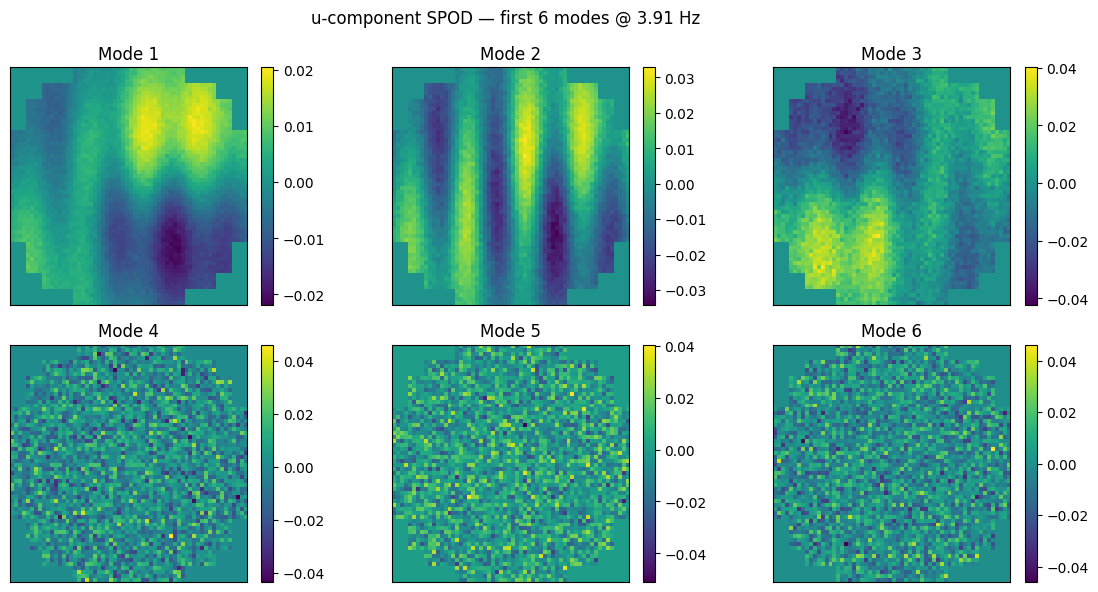

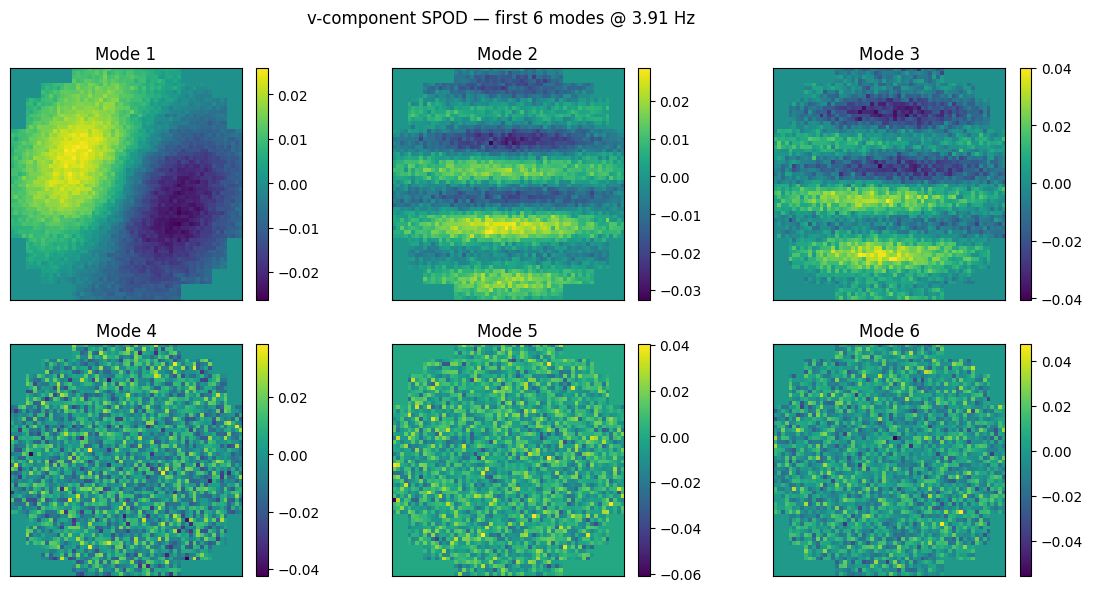

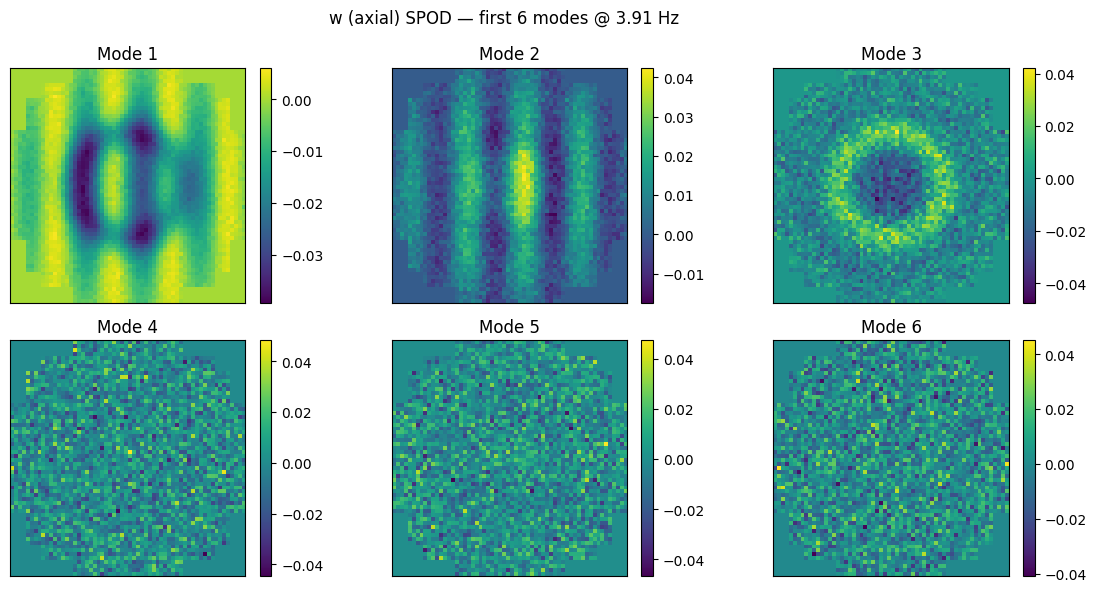

In [4]:
def plot_modes_grid(modes_f, mask, H, W, title_prefix, fval, rows=2, cols=3):
    plt.figure(figsize=(12, 6))
    for i in range(rows*cols):
        if i >= modes_f.shape[1]: break
        ax = plt.subplot(rows, cols, i+1)
        img = unmask(np.real(modes_f[:, i]), mask, H, W)
        im = ax.imshow(img, origin='lower')
        ax.set_title(f'Mode {i+1}')
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle(f'{title_prefix} — first 6 modes @ {fval:.2f} Hz', y=0.98)
    plt.tight_layout()
    plt.show()

# u component
plot_modes_grid(modes_u[fi_u, :, :], mask, H, W, 'u-component SPOD', f_u)

# v component
plot_modes_grid(modes_v[fi_v, :, :], mask, H, W, 'v-component SPOD', f_v)

# w (axial) component
plot_modes_grid(modes_w[fi_w, :, :], mask, H, W, 'w (axial) SPOD', f_w)


## 5) Remarks
- The **axial `w`** field has a strong mean and larger coherent fluctuations, so its SPOD spectrum typically shows higher energy levels than `u`/`v`.
- Frequency peaks (near 4 Hz and 8 Hz here) should be evident across components, with `w` dominating.
- Swap in your real data by replacing `(u,v,w)` and keeping the same mask workflow and SPOD settings.



# Appendix — Window Length & Overlap: What They Do and How to Choose

**Key idea.** SPOD diagonalizes the **cross-spectral density (CSD)** at each frequency. With Welch’s method,
you *estimate* the CSD using windowed, overlapping time blocks. **Changing window length (`nfft`) and overlap**
does **not** change the eigenproblem’s *form*—it changes the **quality of the CSD estimate**:

- **Window length (`nfft`) → time span `T_w = nfft·dt` and frequency resolution `Δf = 1/T_w`.**
  Longer windows sharpen frequency discrimination (narrower peaks) but reduce the number of blocks `K` → higher estimator variance.
  Shorter windows blur frequencies but increase `K` → lower variance.
- **Overlap (e.g., 50% or 75%)** increases `K` (more blocks) without changing `Δf`.
  More overlap → smoother (lower-variance) spectra, but blocks are correlated so the *effective* independence is < `K`.
- **Window shape (Hann here)** controls spectral leakage; its **equivalent noise bandwidth (ENBW)** slightly broadens peaks.
  For Hann, ENBW ≈ 1.5 frequency bins.

Below we print the metrics for several settings, then compare spectra/modes for the axial component `w`.


In [5]:
import numpy as np

def window_metrics(nfft, overlap, dt, window='hann'):
    fs = 1.0/dt
    if window == 'hann':
        w = np.hanning(nfft)
    else:
        raise ValueError("Only 'hann' is supported in this demo.")
    Tw = nfft*dt                          # time span per block [s]
    df = 1.0/Tw                           # frequency resolution [Hz]
    hop = int(nfft*(1-overlap))           # step in samples
    enbw_bins = nfft * (w**2).sum() / (w.sum()**2)   # ENBW in bins
    enbw_hz = enbw_bins * fs / nfft
    return dict(nfft=nfft, overlap=overlap, Tw=Tw, df=df, hop=hop, enbw_bins=enbw_bins, enbw_hz=enbw_hz)

# Example settings (based on this notebook's data rate)
settings = [
    dict(name="Short window", nfft=128, overlap=0.5),
    dict(name="Medium window", nfft=256, overlap=0.5),
    dict(name="High overlap", nfft=256, overlap=0.75),
    dict(name="Long window", nfft=512, overlap=0.5),
]

metrics = []
for s in settings:
    m = window_metrics(s["nfft"], s["overlap"], dt, window='hann')
    # Estimate number of Welch blocks K for the current T (same formula used in analysis code)
    Ttotal = u.shape[0]
    K = 1 + max(0, (Ttotal - s["nfft"]) // m["hop"])
    m["K_blocks"] = K
    m["name"] = s["name"]
    metrics.append(m)

metrics

[{'nfft': 128,
  'overlap': 0.5,
  'Tw': 1.28,
  'df': 0.78125,
  'hop': 64,
  'enbw_bins': np.float64(1.5118110236220472),
  'enbw_hz': np.float64(1.1811023622047243),
  'K_blocks': 15,
  'name': 'Short window'},
 {'nfft': 256,
  'overlap': 0.5,
  'Tw': 2.56,
  'df': 0.390625,
  'hop': 128,
  'enbw_bins': np.float64(1.5058823529411764),
  'enbw_hz': np.float64(0.5882352941176471),
  'K_blocks': 7,
  'name': 'Medium window'},
 {'nfft': 256,
  'overlap': 0.75,
  'Tw': 2.56,
  'df': 0.390625,
  'hop': 64,
  'enbw_bins': np.float64(1.5058823529411764),
  'enbw_hz': np.float64(0.5882352941176471),
  'K_blocks': 13,
  'name': 'High overlap'},
 {'nfft': 512,
  'overlap': 0.5,
  'Tw': 5.12,
  'df': 0.1953125,
  'hop': 256,
  'enbw_bins': np.float64(1.5029354207436396),
  'enbw_hz': np.float64(0.2935420743639921),
  'K_blocks': 3,
  'name': 'Long window'}]


The table above shows, for each setting:

- `Tw` = block duration, `Δf` = frequency resolution, `K_blocks` = number of Welch blocks (higher → smoother estimates),
- `ENBW` (in bins and Hz) = intrinsic frequency-domain smoothing from the Hann window.
Larger `nfft` → smaller `Δf` (sharper peaks) but fewer blocks. Larger overlap → more blocks (smoother) at fixed `nfft`.



## Comparison demo (axial `w`): spectra and mode shapes across settings
We recompute SPOD for `w` with various (nfft, overlap) and compare:
1) **Leading eigenvalue spectra** (expect sharper peaks for longer windows; smoother curves for higher overlap).  
2) **First 6 modes at the peak frequency** for each setting (to see if shapes are stable).


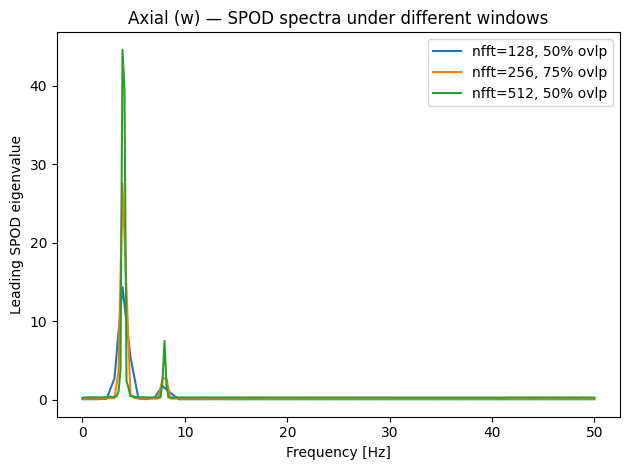

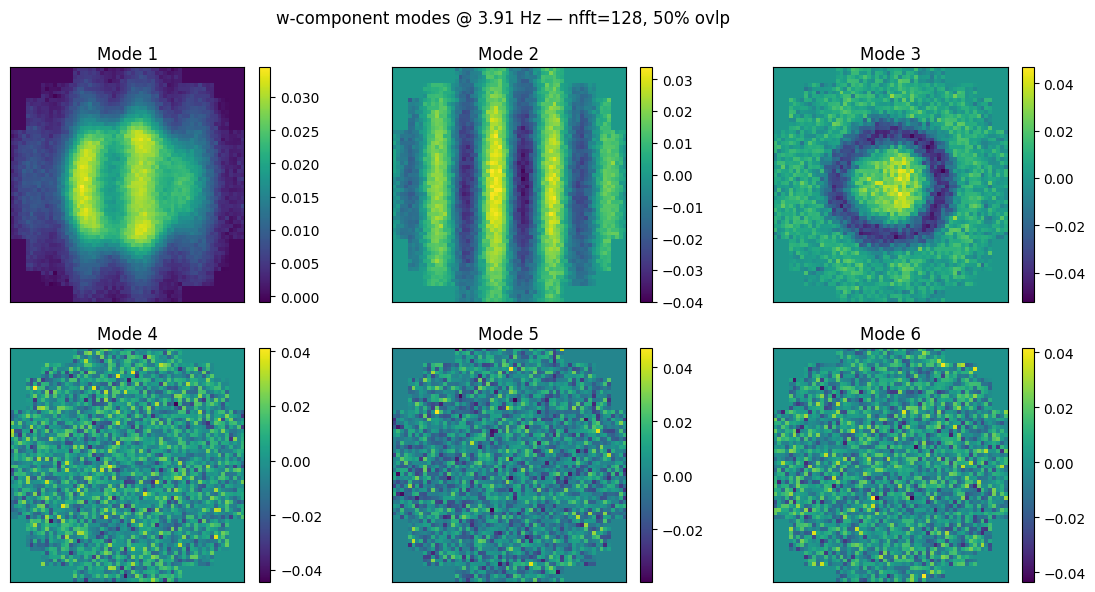

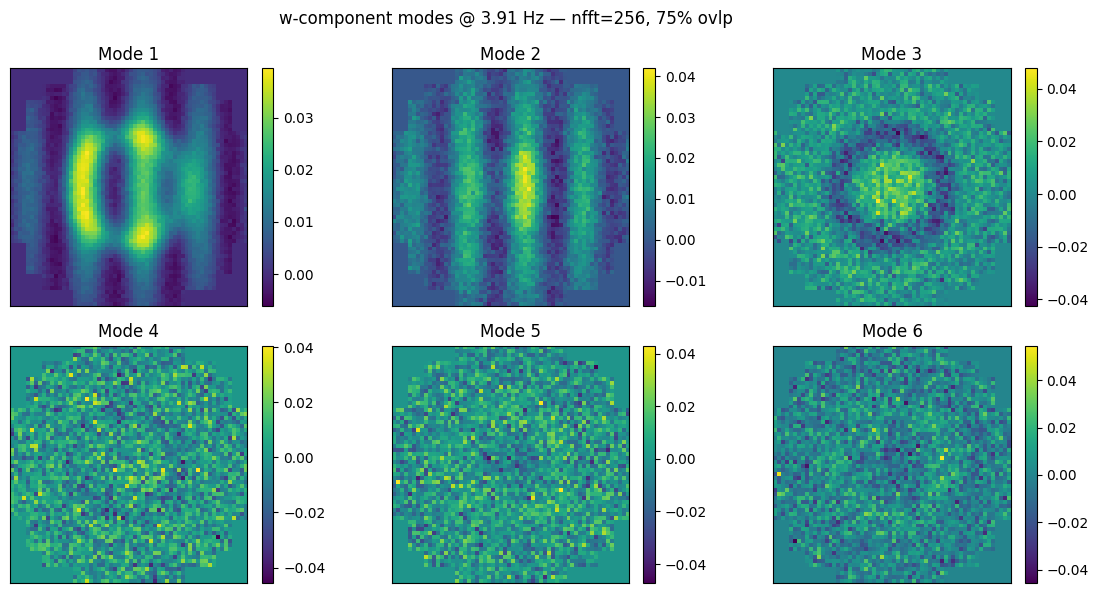

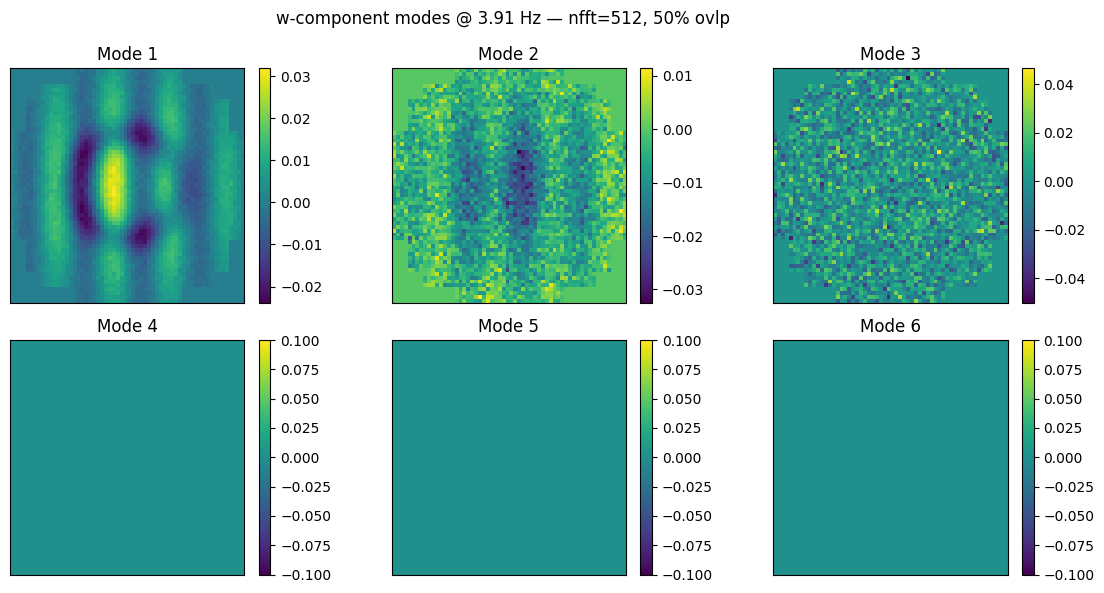

In [6]:
import matplotlib.pyplot as plt

def welch_blocks_scalar(Xc, nfft, overlap, dt):
    M, T = Xc.shape
    hop = int(nfft*(1-overlap))
    win = np.hanning(nfft)
    F = nfft//2 + 1
    blocks = []
    for t0 in range(0, T - nfft + 1, hop):
        seg = Xc[:, t0:t0+nfft] * win[None, :]
        Xhat = np.fft.rfft(seg, axis=1)  # (M x F)
        blocks.append(Xhat)
    Xhat_blocks = np.stack(blocks, axis=0)   # (K x M x F)
    freqs = np.fft.rfftfreq(nfft, d=dt)
    win_norm = (win**2).sum()
    return Xhat_blocks, freqs, win_norm

def spod_component_given_params(stack, mask, dt, nfft, overlap, nmodes=6):
    # Centered masked matrix
    T, H, W = stack.shape
    midx = mask
    M = int(midx.sum())
    X = np.zeros((M, T), dtype=float)
    for k in range(T):
        X[:, k] = stack[k][midx]
    mean = X.mean(axis=1, keepdims=True)
    Xc = X - mean

    Xhat_blocks, freqs, win_norm = welch_blocks_scalar(Xc, nfft, overlap, dt)
    K, M, F = Xhat_blocks.shape
    evals_top = np.zeros((F, nmodes))
    modes_top = np.zeros((F, M, nmodes), dtype=complex)

    for fi in range(F):
        Y = (Xhat_blocks[:, :, fi].T) / np.sqrt(win_norm)   # (M x K)
        C = (Y.conj().T @ Y) / K                            # (K x K)
        lam, Alpha = np.linalg.eigh(C)
        idx = np.argsort(lam)[::-1]
        lam = lam[idx]; Alpha = Alpha[:, idx]
        for m in range(min(nmodes, len(lam))):
            if lam[m] <= 0: continue
            phi = (Y @ Alpha[:, m]) / np.sqrt(K*lam[m])
            evals_top[fi, m] = lam[m]
            modes_top[fi, :, m] = phi
    return freqs, evals_top, modes_top

# Run for three settings to keep it light
compare = [
    dict(label="nfft=128, 50% ovlp", nfft=128, overlap=0.5),
    dict(label="nfft=256, 75% ovlp", nfft=256, overlap=0.75),
    dict(label="nfft=512, 50% ovlp", nfft=512, overlap=0.5),
]

results = []
for cfg in compare:
    fz, ev, md = spod_component_given_params(w, mask, dt, cfg["nfft"], cfg["overlap"], nmodes=6)
    results.append((cfg, fz, ev, md))

# Plot leading spectra overlay
plt.figure()
for (cfg, fz, ev, md) in results:
    plt.plot(fz, ev[:,0], label=cfg["label"])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Leading SPOD eigenvalue")
plt.title("Axial (w) — SPOD spectra under different windows")
plt.legend()
plt.tight_layout()
plt.show()

# Show 2x3 mode grids at each setting's peak frequency
def unmask(vec, mask, H, W):
    img = np.zeros((H, W), dtype=vec.dtype)
    img[mask] = vec
    return img

H, W = mask.shape
for (cfg, fz, ev, md) in results:
    fi = int(np.argmax(ev[:,0]))
    fpk = fz[fi]
    modes_f = md[fi]        # (M, nmodes)
    plt.figure(figsize=(12,6))
    for i in range(6):
        ax = plt.subplot(2,3,i+1)
        img = unmask(np.real(modes_f[:, i]), mask, H, W)
        im = ax.imshow(img, origin='lower')
        ax.set_title(f"Mode {i+1}")
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle(f"w-component modes @ {fpk:.2f} Hz — {cfg['label']}", y=0.98)
    plt.tight_layout()
    plt.show()


### Takeaways
- **Longer windows (larger `nfft`)** → **sharper peaks** and better separation of nearby tones, but **fewer blocks** → spectra can look more ragged (higher variance) unless you also increase overlap or total data length.
- **Higher overlap** (e.g., 75%) at fixed `nfft` → **smoother spectra** (more averages) with **unchanged frequency resolution**.
- **Mode shapes** at clear peaks tend to be **stable** across reasonable settings; large changes suggest the peak is not well resolved or the estimate is too noisy.
